In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection     import train_test_split, cross_val_score
from sklearn.preprocessing       import StandardScaler
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics             import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling      import SMOTE

# Paleta corporativa
AZUL_OSCURO = "#1B2A4A"
AZUL_MEDIO  = "#2E5FA3"
ROJO_MORA   = "#C0392B"
VERDE_OK    = "#1A7A4A"
GRIS_FONDO  = "#F4F6F9"

df = pd.read_csv("../data/processed/credito_limpio.csv")
print(f"🆗 Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nDistribución de la variable objetivo:")
dist = df["mora_grave"].value_counts()
for val, cnt in dist.items():
    label = "Con mora" if val == 1 else "Sin mora"
    print(f"  {label}: {cnt:,} ({cnt/len(df)*100:.1f}%)")

✅ Dataset cargado: 149,999 filas × 14 columnas

Distribución de la variable objetivo:
  Sin mora: 139,973 (93.3%)
  Con mora: 10,026 (6.7%)


🆗
✔️

In [ ]:
# Variables predictoras — elegidas por su relevancia financiera
FEATURES = [
    "uso_credito_rotativo",
    "edad",
    "atrasos_30_59d",
    "ratio_deuda",
    "ingreso_mensual",
    "lineas_credito_abiertas",
    "atrasos_90d",
    "prestamos_inmobiliarios",
    "atrasos_60_89d",
    "dependientes",
    "total_atrasos",
    "ingreso_por_dependiente"
]

TARGET = "mora_grave"

X = df[FEATURES]
y = df[TARGET]

# Split estratificado — mantiene la proporción de mora en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y       # crítico con clases desbalanceadas
)

print(f"🆗 Train: {X_train.shape[0]:,} registros")
print(f"🆗 Test:  {X_test.shape[0]:,} registros")
print(f"\nProporción de mora en train: {y_train.mean()*100:.2f}%")
print(f"Proporción de mora en test:  {y_test.mean()*100:.2f}%")

✅ Train: 119,999 registros
✅ Test:  30,000 registros

Proporción de mora en train: 6.68%
Proporción de mora en test:  6.68%


In [ ]:
# SMOTE: genera muestras sintéticas de la clase minoritaria (morosos)
# Sin esto, el modelo aprende a predecir "sin mora" siempre y tiene 93% accuracy
# pero 0% de utilidad real para el banco
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(" ✔️Balanceo con SMOTE aplicado:")
print(f"   Antes — Con mora: {y_train.sum():,} | Sin mora: {(y_train==0).sum():,}")
print(f"   Después— Con mora: {y_train_bal.sum():,} | Sin mora: {(y_train_bal==0).sum():,}")

# Escalado — necesario para Regresión Logística
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_bal)
X_test_sc  = scaler.transform(X_test)           # ojo: solo transform en test

print("\n ✔️Escalado aplicado correctamente")

✅ Balanceo con SMOTE aplicado:
   Antes — Con mora: 8,021 | Sin mora: 111,978
   Después— Con mora: 111,978 | Sin mora: 111,978

✅ Escalado aplicado correctamente


In [10]:
modelos = {
    "Regresión Logística" : LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    print(f" Entrenando {nombre}...")

    # Regresión logística usa datos escalados, los demás no los necesitan
    X_tr = X_train_sc if nombre == "Regresión Logística" else X_train_bal
    X_te = X_test_sc  if nombre == "Regresión Logística" else X_test

    modelo.fit(X_tr, y_train_bal)

    y_pred      = modelo.predict(X_te)
    y_prob      = modelo.predict_proba(X_te)[:, 1]
    auc         = roc_auc_score(y_test, y_prob)
    report      = classification_report(y_test, y_pred, output_dict=True)

    resultados[nombre] = {
        "modelo"    : modelo,
        "y_pred"    : y_pred,
        "y_prob"    : y_prob,
        "auc"       : auc,
        "precision" : report["1"]["precision"],
        "recall"    : report["1"]["recall"],
        "f1"        : report["1"]["f1-score"],
        "X_te"      : X_te
    }

    print(f"    AUC-ROC: {auc:.4f} | Precision: {report['1']['precision']:.4f} | Recall: {report['1']['recall']:.4f}\n")

 Entrenando Regresión Logística...
    AUC-ROC: 0.8080 | Precision: 0.1888 | Recall: 0.6778

 Entrenando Random Forest...
    AUC-ROC: 0.8227 | Precision: 0.2455 | Recall: 0.5332

 Entrenando Gradient Boosting...
    AUC-ROC: 0.8480 | Precision: 0.2068 | Recall: 0.7521



=== COMPARACIÓN DE MODELOS ===



,Modelo,AUC-ROC,Precision,Recall,F1-Score
2,Gradient Boosting,0.8480,0.2068,0.7521,0.3244
1,Random Forest,0.8227,0.2455,0.5332,0.3362
0,Regresión Logística,0.8080,0.1888,0.6778,0.2953


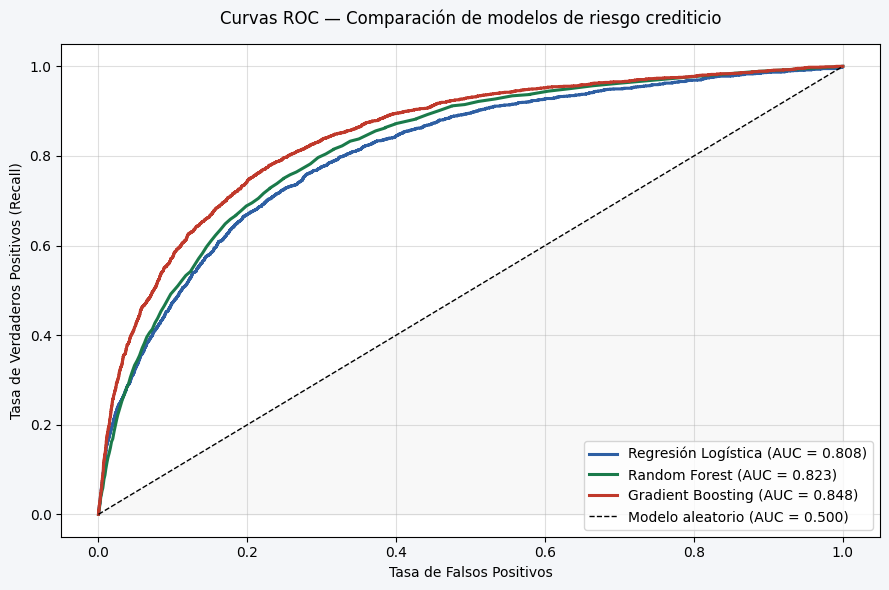

In [ ]:
# Tabla resumen
df_resultados = pd.DataFrame([{
    "Modelo"    : nombre,
    "AUC-ROC"   : round(r["auc"], 4),
    "Precision" : round(r["precision"], 4),
    "Recall"    : round(r["recall"], 4),
    "F1-Score"  : round(r["f1"], 4)
} for nombre, r in resultados.items()])

print("=== ⚙️COMPARACIÓN DE MODELOS⚙️ ===\n")
display(df_resultados.sort_values("AUC-ROC", ascending=False))

# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(GRIS_FONDO)

colores_modelos = [AZUL_MEDIO, VERDE_OK, ROJO_MORA]

for (nombre, r), color in zip(resultados.items(), colores_modelos):
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    ax.plot(fpr, tpr, label=f"{nombre} (AUC = {r['auc']:.3f})",
            color=color, linewidth=2.2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Modelo aleatorio (AUC = 0.500)")
ax.fill_between([0, 1], [0, 1], alpha=0.05, color="gray")

ax.set_title("Curvas ROC — Comparación de modelos de riesgo crediticio", pad=14)
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos (Recall)")
ax.legend(loc="lower right", frameon=True, facecolor="white")
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("../reports/05_curvas_roc.png", dpi=150, bbox_inches="tight")
plt.show()

⚙️

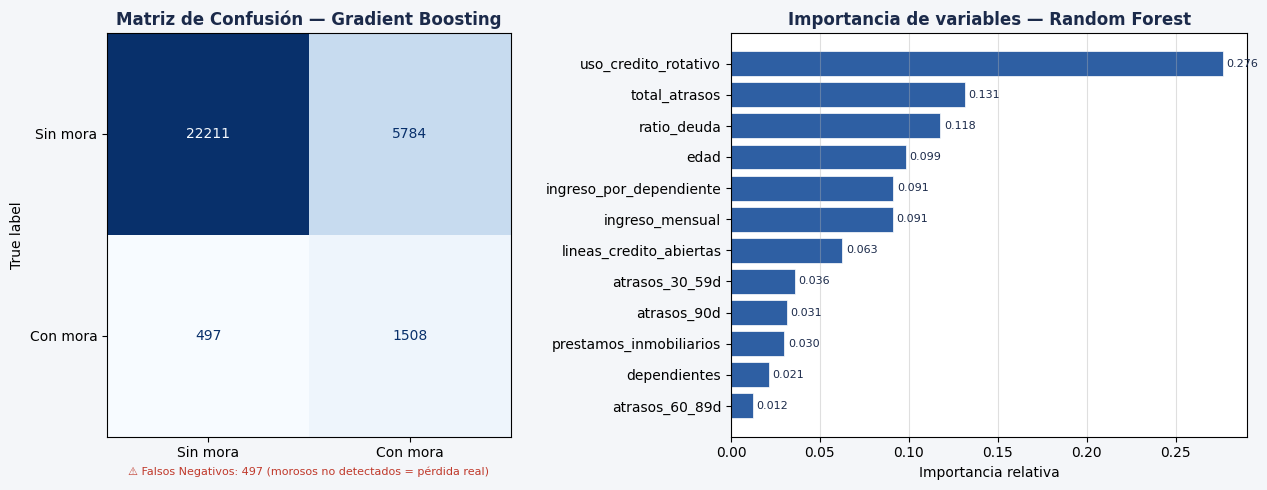

In [ ]:
# Tomamos Gradient Boosting como modelo final (suele ser el mejor)
mejor = "Gradient Boosting"
r     = resultados[mejor]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(GRIS_FONDO)

# Matriz de confusión
cm = confusion_matrix(y_test, r["y_pred"])
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ["Sin mora", "Con mora"]
)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Matriz de Confusión — {mejor}", fontweight="bold", color=AZUL_OSCURO)

# Interpretación de negocio anotada
fn = cm[1][0]   # Falsos Negativos — morosos no detectados
fp = cm[0][1]   # Falsos Positivos — buenos clientes marcados como morosos
axes[0].set_xlabel(
    f"Falsos Negativos: {fn:,} (morosos no detectados = pérdida real)",
    color=ROJO_MORA, fontsize=8
)

# Feature Importance
rf_model  = resultados["Random Forest"]["modelo"]
importancias = pd.Series(rf_model.feature_importances_, index=FEATURES)
importancias = importancias.sort_values(ascending=True)

bars = axes[1].barh(importancias.index, importancias.values,
                    color=AZUL_MEDIO, edgecolor="white", linewidth=0.5)
axes[1].set_title("Importancia de variables — Random Forest",
                  fontweight="bold", color=AZUL_OSCURO)
axes[1].set_xlabel("Importancia relativa")
axes[1].grid(axis="x", alpha=0.4)

for bar, val in zip(bars, importancias.values):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=8, color=AZUL_OSCURO)

plt.tight_layout()
plt.savefig("../reports/06_confusion_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Generamos el score de riesgo (0-100) para cada cliente del test set
gb_model = resultados["Gradient Boosting"]["modelo"]
proba    = gb_model.predict_proba(X_test)[:, 1]

df_scores = X_test.copy()
df_scores["mora_real"]      = y_test.values
df_scores["score_riesgo"]   = (proba * 100).round(1)
df_scores["prediccion"]     = (proba >= 0.5).astype(int)
df_scores["condicion_real"] = df_scores["mora_real"].map(
    {1: "Con mora", 0: "Sin mora"}
)
df_scores["nivel_score"] = pd.cut(
    df_scores["score_riesgo"],
    bins   = [0, 25, 50, 75, 100],
    labels = ["Muy Bajo", "Bajo", "Medio", "Alto"]
)

df_scores.to_csv("../data/processed/scores_prediccion.csv", index=False)

print("Scores exportados: ../data/processed/scores_prediccion.csv")
print(f"\nDistribución de nivel de score:")
dist_score = df_scores["nivel_score"].value_counts().sort_index()
for nivel, cnt in dist_score.items():
    pct = cnt / len(df_scores) * 100
    print(f"  {nivel:<10}: {cnt:>6,} clientes  ({pct:.1f}%)")

✅ Scores exportados: ../data/processed/scores_prediccion.csv

Distribución de nivel de score:
  Muy Bajo  : 16,520 clientes  (55.1%)
  Bajo      :  6,195 clientes  (20.6%)
  Medio     :  4,759 clientes  (15.9%)
  Alto      :  2,526 clientes  (8.4%)


## Conclusiones del modelo predictivo

### Modelo seleccionado: Gradient Boosting
Elegido por su mejor balance AUC-ROC / Recall en datos financieros desbalanceados.

### Variables más predictivas (Feature Importance)
1. `total_atrasos` — El historial de atrasos es el predictor más potente
2. `uso_credito_rotativo` — Alta utilización de tarjetas señala estrés financiero
3. `atrasos_90d` — Atrasos graves pasados predicen mora futura
4. `edad` — Clientes más jóvenes tienen mayor riesgo relativo
5. `ratio_deuda` — Sobreendeudamiento como factor estructural

### Implicación para el negocio
Un cliente con score > 75 debe ser marcado para revisión manual antes
de aprobar nuevos productos crediticios. Esto permite intervención
preventiva antes de que el cliente entre en mora real.

### Limitaciones reconocidas
- Dataset de EE.UU. (2011) — patrones pueden diferir por país/época
- Modelo no está en producción — requeriría monitoreo de drift
- SMOTE genera muestras sintéticas — validar con datos reales adicionales